# Bifurcation analysis — trained neural-network mean field (QIF)

Continuation of the trained `mlp_qif` mean-field model with
[BifurcationKit.jl](https://github.com/bifurcation-kit/BifurcationKit.jl).
Reads the trained weights from `../data/results/mlp_qif_params.pkl` and writes
the `mlp_qif*` curves to `../data/results/bifurcation_analysis/`.

**Scope:** this notebook produces only the `mlp_qif*` curves. The `mpr*`
(Montbrió–Pazó–Roxin) and `mlp_fre*` (firing-rate-equation) curves read by the
figure are generated separately and are not produced here. The final cell
regenerates every `mlp_qif_cusp_p*` CSV used by the p-dependence cusp figure.


In [1]:
using SciPyDiffEq, LinearAlgebra, FiniteDiff, ForwardDiff
using PyCall, Setfield
using Pandas: read_pickle
using Revise, Plots
using BifurcationKit
using NPZ
const BK = BifurcationKit
using AsymptoticNumericalMethod
using JLD2
using CSV
using LaTeXStrings

In [5]:
pars = read_pickle("../data/results/mlp_qif_params.pkl")
pars = pars["dfun"]
w1 = pars["layers_0"]["kernel"]
b1 = pars["layers_0"]["bias"]
w2 = pars["layers_1"]["kernel"]
b2 = pars["layers_1"]["bias"]
wo = pars["output"]["kernel"]
bo = pars["output"]["bias"]
np = pyimport("numpy")

w1 = convert(Matrix{Float32}, np.array(w1))
b1 = convert(Vector{Float32}, np.array(b1))
w2 = convert(Matrix{Float32}, np.array(w2))
b2 = convert(Vector{Float32}, np.array(b2))
wo = convert(Matrix{Float32}, np.array(wo))
bo = convert(Vector{Float32}, np.array(bo))

2-element Vector{Float32}:
 0.24587463
 0.06540276

In [6]:
function MLP(state, p, t)
    r, v = state
    x = [r, v, p.eta, p.synap, p.j, p.I]
    
    # Forward pass through the network
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,6)))*wo+reshape(bo, (1,2))
    # Set derivatives (du) for the state variables
    [
        output[1],
        output[2]
    ]
end

# Initial conditions and time span
initial_state = [.5,-2.1]
tspan = (0.0, 1000.0)

# Parameters passed to MLP function
p = (eta=-5., I=0., j=15., synap=1.0, w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)

# Define the ODE problem
prob = ODEProblem(MLP, initial_state, tspan, p)

# Solve the ODE using SciPyDiffEq's odeint solver
sol = SciPyDiffEq.solve(prob, SciPyDiffEq.odeint(), reltol=1e-10, abstol=1e-10)


retcode: Success
Interpolation: 1st order linear
t: 2-element Vector{Float64}:
    0.0
 1000.0
u: 2-element Vector{Vector{Float64}}:
 [0.5, -2.1]
 [0.05431449464390937, -1.9222020927405599]

In [34]:
function MLP!(state, p)
    r, v = state
    x = [r, v, p.eta, p.synap, p.J, p.I]
    
    # Forward pass through the network
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,6)))*wo+reshape(bo, (1,2))
    # Set derivatives (du) for the state variables
    [
        output[1],
        output[2]
    ]
end

p = (eta=-5., I=0., J=15., synap=1., w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)
initial_state = sol.u[2]
prob = BifurcationProblem(MLP!, initial_state, p, (@optic _.synap), J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
	record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
# continuation options, we limit the parameter range for E0
opts_br = ContinuationPar(p_min = .5, p_max = 1., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10))

# continuation of equilibria
br = continuation(prob, PALC(), opts_br,
	# we want to compute both sides of the branch of the initial
	# value of E0 = -2
bothside = true, verbosity=0)




 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 53
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter synap starts at 0.5, ends at 1.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at synap ≈ +0.50000000,                                                                     step =   0
- #  2, endpoint at synap ≈ +1.00000000,                                                                     step =  52


In [8]:
function MLP!(state, p)
    r, v = state
    x = [r, v, p.eta, p.synap, p.J, p.I]
    
    # Forward pass through the network
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,6)))*wo+reshape(bo, (1,2))
    # Set derivatives (du) for the state variables
    [
        output[1],
        output[2]
    ]
end

p = (eta=-5., I=0., J=15., synap=1., w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)
initial_state = sol.u[2]
prob = BifurcationProblem(MLP!, initial_state, p, (@optic _.eta), J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
	record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
# continuation options, we limit the parameter range for E0
opts_br = ContinuationPar(p_min = -10.0, p_max = 0., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10))


# continuation of equilibria
br = continuation(prob, PALC(), opts_br,
	# we want to compute both sides of the branch of the initial
	# value of E0 = -2
bothside = true, verbosity=0)




 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 1112
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter eta starts at -10.0, ends at 0.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at eta ≈ -10.00000000,                                                                     step =   0
- #  2,       bp at eta ≈ -3.22780136 ∈ (-3.22780197, -3.22780136), |δp|=6e-07, [converged], δ = ( 1,  0), step = 519
- #  3,       bp at eta ≈ -5.68176781 ∈ (-5.68176781, -5.68171432), |δp|=5e-05, [converged], δ = (-1,  0), step = 705
- #  4, endpoint at eta ≈ +0.00000000,                                                                     step = 1111


In [14]:
println(br.specialpoint[2].type)
println(br.specialpoint[2].printsol)
J_at_point = ForwardDiff.jacobian(z -> MLP!(z, p), [br.specialpoint[2].printsol.r, br.specialpoint[2].printsol.v])
println(det(J_at_point), "  ", cond(J_at_point))

bp
(r = 0.1375556651831603, v = -1.0024330570504358)
0.0006066535889338043  1656.2628189989923


In [26]:
function guard_cb(state; kwargs...)
    if state.residual > 1.0 || any(!isfinite, state.x)
        return false   # abort this Newton attempt; continuation will shrink ds and retry
    end
    return true
end

J_eta = continuation(br, 2, (@optic _.J),
    ContinuationPar(opts_br, p_min=.0, p_max=20., dsmin=0.00001, ds=0.0001, dsmax=0.005,
                    max_steps=100000, newton_options=NewtonPar(tol=1e-12, max_iterations=6));
    bothside=true, detect_codim2_bifurcation=2, a=[1.0,0.0], b=[0.0,1.0],
    callback_newton = guard_cb)

 ┌─ Curve type: FoldCont
 ├─ Number of points: 3708
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameters (:eta, :J)
 ├─ Parameter J starts at 20.0, ends at 20.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at J ≈ +20.00000000,                                                                     step =   0
- #  2,     cusp at J ≈ +7.52438946 ∈ (+7.52438931, +7.52438946), |δp|=1e-07, [converged], δ = ( 0,  0), step = 1902
- #  3, endpoint at J ≈ +20.00000000,                                                                     step = 3707


In [27]:
for i in 1:length(J_eta.specialpoint)
    if J_eta.specialpoint[i].type==:cusp
        println("Cusp point found at eta = ", [J_eta.specialpoint[i].printsol.eta])
    end
end


Cusp point found at eta = [-1.656432573401871]


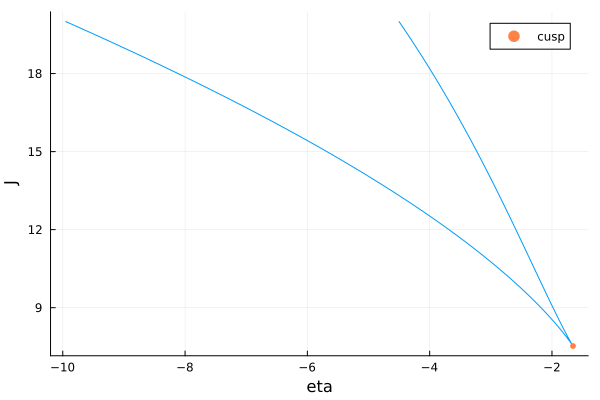

In [28]:
plot(J_eta, vars = (:eta, :J))

In [29]:
J_eta.specialpoint[2].printsol.eta, J_eta.specialpoint[2].printsol.J

(-1.656432573401871, 7.524389455719402)

In [30]:
CSV.write("../data/results/bifurcation_analysis/mlp_qif_cusp.csv", (j=J_eta.J, eta=J_eta.eta))


"../data/results/bifurcation_analysis/mlp_qif_cusp_p1.csv"

In [31]:
I_d = continuation(br, 2, (@optic _.I), 
	ContinuationPar(opts_br, p_min=-20., p_max = 20., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)

I_u = continuation(br, 3, (@optic _.I), 
	ContinuationPar(opts_br, p_min=-20., p_max = 20., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)

 ┌─ Curve type: FoldCont
 ├─ Number of points: 3286
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameters (:eta, :I)
 ├─ Parameter I starts at -20.0, ends at 20.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at I ≈ -20.00000000,                                                                     step =   0
- #  2, endpoint at I ≈ +20.00000000,                                                                     step = 3285


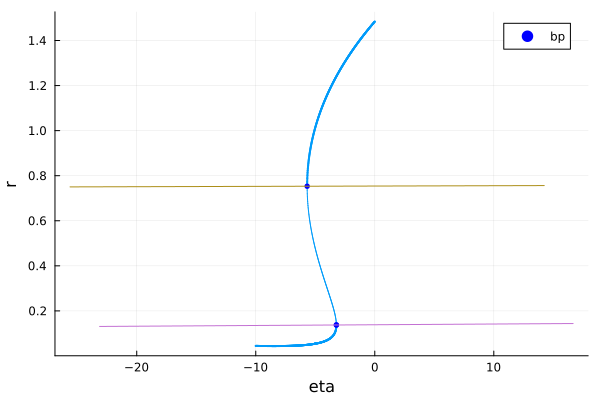

In [32]:
plot(br)
plot!(I_d, vars = (:eta, :r))
plot!(I_u, vars = (:eta, :r))

In [33]:
p_eta = continuation(br, 2, (@optic _.synap), 
	ContinuationPar(opts_br, p_min=.0, p_max = 1., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)

 ┌─ Curve type: FoldCont
 ├─ Number of points: 261
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameters (:eta, :synap)
 ├─ Parameter synap starts at 1.0, ends at 1.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at synap ≈ +1.00000000,                                                                     step =   0
- #  2,     cusp at synap ≈ +0.42049748 ∈ (+0.42049748, +0.42049748), |δp|=5e-12, [   guessL], δ = ( 0,  0), step = 169
- #  3,     cusp at synap ≈ +1.00000000 ∈ (+1.00000000, +1.00000000), |δp|=0e+00, [converged], δ = ( 0,  0), step = 260
- #  4, endpoint at synap ≈ +1.00000000,                                                                     step = 260


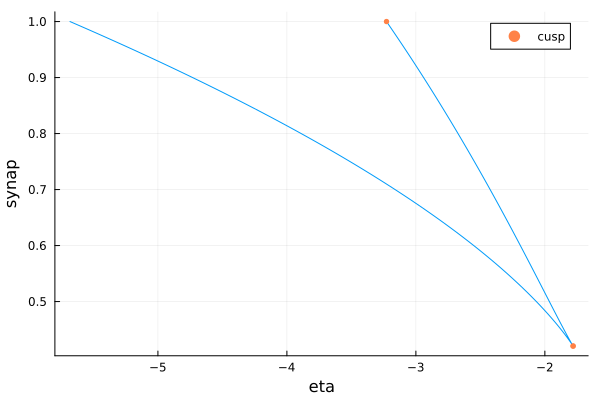

In [34]:
plot(p_eta, vars = (:eta, :synap))

In [37]:
types = String[]
rs = []
vs = []
for point in br.specialpoint
    push!(types, String(point.type))
    push!(rs, point.printsol[1])
    push!(vs, point.printsol[2])
end

CSV.write("../data/results/bifurcation_analysis/mlp_qif.csv", (r = br.branch.r, v = br.branch.v, eta = br.branch.param, stable = br.branch.stable))

"../data/results/bifurcation_analysis/mlp_qif.csv"

In [57]:
function MLP!(state, p)
    r, v = state
    x = [r, v, p.eta, p.synap, p.J, p.I]
    
    # Forward pass through the network
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,6)))*wo+reshape(bo, (1,2))
    # Set derivatives (du) for the state variables
    [
        output[1],
        output[2]
    ]
end

p = (eta=-5., I=0., J=15., synap=1., w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)
initial_state = sol.u[2]
prob = BifurcationProblem(MLP!, initial_state, p, (@optic _.eta), J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
	record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
# continuation options, we limit the parameter range for E0
opts_br = ContinuationPar(p_min = -10., p_max = 0., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10))

# continuation of equilibria
br = continuation(prob, PALC(), opts_br,
	# we want to compute both sides of the branch of the initial
	# value of E0 = -2
bothside = true, verbosity=0)


# p_eta = continuation(br, 2, (@optic _.eta), 
# 	ContinuationPar(opts_br, p_min=-10., p_max = -0., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
# 					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
# 	# compute both sides of the initial condition
# 	bothside = true,
# 	# detection of codim 2 bifurcations
# 	detect_codim2_bifurcation=2,
# )

 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 1111
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter eta starts at -10.0, ends at 0.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at eta ≈ -10.00000000,                                                                     step =   0
- #  2,       bp at eta ≈ -3.04018937 ∈ (-3.04024722, -3.04018937), |δp|=6e-05, [converged], δ = ( 1,  0), step = 532
- #  3,       bp at eta ≈ -5.48295344 ∈ (-5.48295344, -5.48277560), |δp|=2e-04, [converged], δ = (-1,  0), step = 718
- #  4, endpoint at eta ≈ +0.00000000,                                                                     step = 1110


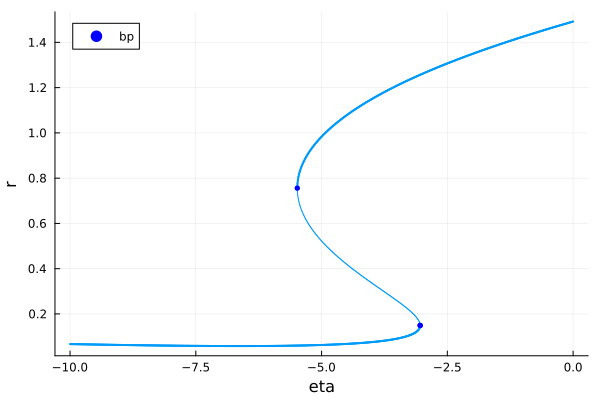

In [58]:
plot(br)

In [59]:
p_eta = continuation(br, 3, (@optic _.synap), 
	ContinuationPar(opts_br, p_min=.5, p_max = 1., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)


 ┌─ Curve type: FoldCont
 ├─ Number of points: 247
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameters (:eta, :synap)
 ├─ Parameter synap starts at 1.0, ends at 1.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at synap ≈ +1.00000000,                                                                     step =   0
- #  2,     cusp at synap ≈ +0.51802316 ∈ (+0.51802316, +0.51802330), |δp|=1e-07, [   guessL], δ = ( 0,  0), step =  70
- #  3,     cusp at synap ≈ +1.00000000 ∈ (+1.00000000, +1.00000000), |δp|=0e+00, [converged], δ = ( 0,  0), step = 246
- #  4, endpoint at synap ≈ +1.00000000,                                                                     step = 246


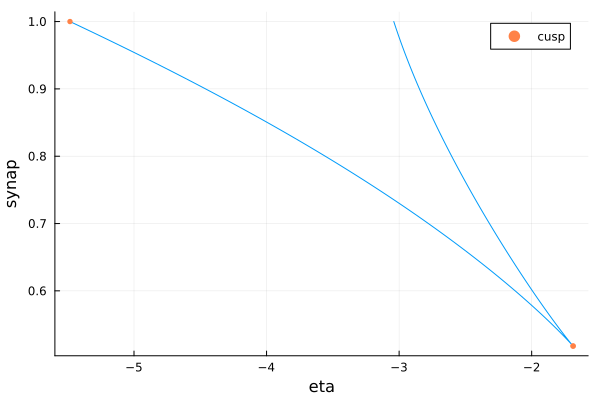

In [60]:
plot(p_eta, vars = (:eta, :synap))

In [61]:
function MLP!(state, p)
    r, v = state
    x = [r, v, p.eta, p.synap, p.j, p.I]
    
    # Forward pass through the network
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,8)))*wo+reshape(bo, (1,2))
    # Set derivatives (du) for the state variables
    [
        output[1],
        output[2]
    ]
end

p = (eta=-5., I=0., j=15., synap=1., w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)
initial_state = sol.u[2]
prob = BifurcationProblem(MLP!, initial_state, p, (@optic _.j), J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
	record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
# continuation options, we limit the parameter range for E0
opts_br = ContinuationPar(p_min = 0., p_max = 35., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10))

# continuation of equilibria
br = continuation(prob, PALC(), opts_br,
    bothside = true, verbosity=0)

# J_down = continuation(br, 2, (@optic _.J), 
# 	ContinuationPar(opts_br, p_min=.0, p_max = 22., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
# 					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
# 	# compute both sides of the initial condition
# 	bothside = true,
# 	# detection of codim 2 bifurcations
# 	detect_codim2_bifurcation=2,
# )

# J_up = continuation(br, 3, (@optic _.J),
# 	ContinuationPar(opts_br, p_min=.0, p_max = 22., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
# 	# compute both sides of the initial condition
# 	bothside = true,
# 	# detection of codim 2 bifurcations
# 	detect_codim2_bifurcation=2,
# )


p_down = continuation(br, 2, (@optic _.synap), 
	ContinuationPar(opts_br, p_min=.0, p_max = 1., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000,
					newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)

p_up = continuation(br, 3, (@optic _.synap),
	ContinuationPar(opts_br, p_min=.0, p_max = 1., dsmin=0.00001, ds=0.0001, dsmax = 0.01, max_steps = 100000, newton_options = NewtonPar(tol = 1e-12,  max_iterations = 10));
	# compute both sides of the initial condition
	bothside = true,
	# detection of codim 2 bifurcations
	detect_codim2_bifurcation=2,
)


DimensionMismatch: DimensionMismatch: new dimensions (1, 8) must be consistent with array length 6

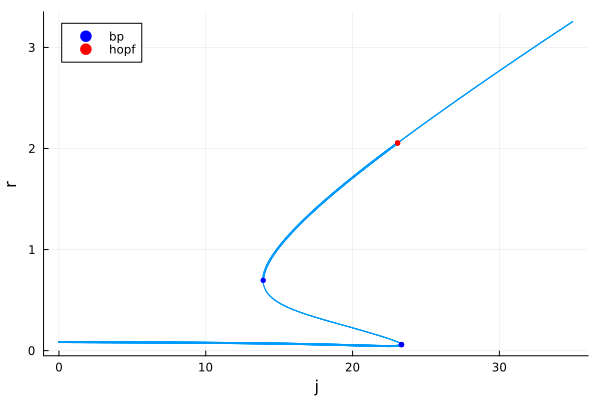

In [ ]:
scene = plot(br, legend=:topleft) 

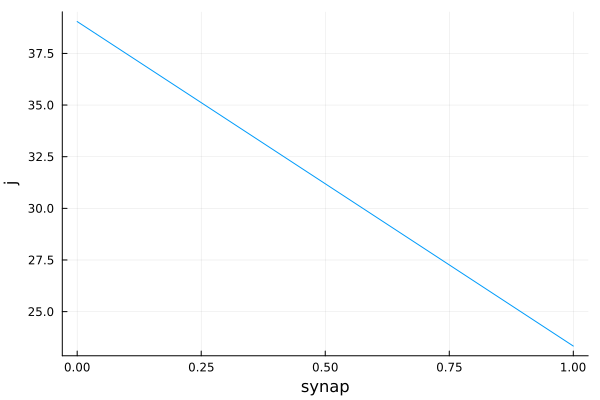

In [44]:
plot(p_down, vars = (:synap, :j))

In [24]:
sol.u[2]

2-element Vector{Float64}:
  0.07573830503802306
 -1.9744429822743017

In [ ]:
# =============================================================================
# Regenerate every CSV consumed by the p-cusp figure
# (notebooks/bifurcation-figures.ipynb, panel set
#  saved as paper_figs/p_cusp.png).
#
# These curves were originally produced by editing `synap` / `J` by hand and
# re-running the continuation cells above, saving under a new name each time.
# Only the last variant survived in the notebook, so the figure could not be
# regenerated from a clean run. The loops below make that sweep explicit.
#
# NOTE ON BRANCH INDICES: the codim-2 continuations start from a branch point of
# `br`, indexed positionally (`continuation(br, 2, ...)`). The cells above use
# index 2 in some cases and 3 in others, because which branch point is the one
# of interest depends on what the eta-continuation detects. If a sweep value
# fails to converge or traces the wrong curve, inspect `br` and adjust `BP_INDEX`.
# =============================================================================

outdir = "../data/results/bifurcation_analysis"
mkpath(outdir)

function MLP!(state, p)
    r, v = state
    x = [r, v, p.eta, p.synap, p.J, p.I]
    output = tanh.(tanh.(w1'*x+b1)'*w2+reshape(b2, (1,6)))*wo+reshape(bo, (1,2))
    [output[1], output[2]]
end

function guard_cb(state; kwargs...)
    if state.residual > 1.0 || any(!isfinite, state.x)
        return false   # abort this Newton attempt; continuation shrinks ds and retries
    end
    return true
end

base_p(; eta=-5., I=0., J=15., synap=1.) =
    (eta=eta, I=I, J=J, synap=synap, w1=w1, b1=b1, w2=w2, b2=b2, wo=wo, bo=bo)

newton_opts = NewtonPar(tol = 1e-12, max_iterations = 10)
BP_INDEX = 2

"eta-continuation of equilibria at fixed (J, synap); the base branch for codim-2."
function eta_branch(; J=15., synap=1.)
    prob = BifurcationProblem(MLP!, sol.u[2], base_p(J=J, synap=synap), (@optic _.eta),
        J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
        record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
    opts = ContinuationPar(p_min = -10., p_max = 0., dsmin=0.00001, ds=0.0001,
                           dsmax = 0.01, max_steps = 100000, newton_options = newton_opts)
    continuation(prob, PALC(), opts; bothside = true, verbosity = 0), opts
end

# --- (1) p-bifurcation diagram: r, v vs synap at J = 15 ----------------------
# The parameter column is `synap` here. The original cell wrote it as `eta`,
# which is what the figure's `x='synap'` lookup needed but did not get.
let
    prob = BifurcationProblem(MLP!, sol.u[2], base_p(), (@optic _.synap),
        J = (x, p) -> ForwardDiff.jacobian(z -> MLP!(z, p), x);
        record_from_solution = (x, p; k...) -> (r=x[1], v=x[2]))
    opts = ContinuationPar(p_min = .5, p_max = 1., dsmin=0.00001, ds=0.0001,
                           dsmax = 0.01, max_steps = 100000, newton_options = newton_opts)
    br_p = continuation(prob, PALC(), opts; bothside = true, verbosity = 0)
    CSV.write("$outdir/mlp_qif_p_bifurc.csv",
              (r = br_p.branch.r, v = br_p.branch.v,
               synap = br_p.branch.param, stable = br_p.branch.stable))
    println("wrote mlp_qif_p_bifurc.csv")
end

# --- (2) J-eta cusp at fixed p  ->  mlp_qif_cusp_p{6,8,1}.csv ----------------
# Suffix follows the figure's labels: "6" -> p=0.6, "8" -> p=0.8, "1" -> p=1.0
for (label, pval) in [("6", 0.6), ("8", 0.8), ("1", 1.0)]
    br, opts = eta_branch(synap = pval)
    J_eta = continuation(br, BP_INDEX, (@optic _.J),
        ContinuationPar(opts, p_min=.0, p_max=20., dsmin=0.00001, ds=0.0001, dsmax=0.005,
                        max_steps=100000, newton_options=NewtonPar(tol=1e-12, max_iterations=6));
        bothside=true, detect_codim2_bifurcation=2, a=[1.0,0.0], b=[0.0,1.0],
        callback_newton = guard_cb)
    CSV.write("$outdir/mlp_qif_cusp_p$(label).csv", (j = J_eta.J, eta = J_eta.eta))
    println("wrote mlp_qif_cusp_p$(label).csv  (p = $pval)")
end

# --- (3) p-eta cusp at fixed J  ->  mlp_qif_cusp_p_J{12,16,20}.csv -----------
for Jval in [12, 16, 20]
    br, opts = eta_branch(J = Float64(Jval))
    p_eta = continuation(br, BP_INDEX, (@optic _.synap),
        ContinuationPar(opts, p_min=.0, p_max=1., dsmin=0.00001, ds=0.0001, dsmax=0.01,
                        max_steps=100000, newton_options=newton_opts);
        bothside=true, detect_codim2_bifurcation=2,
        callback_newton = guard_cb)
    CSV.write("$outdir/mlp_qif_cusp_p_J$(Jval).csv", (p = p_eta.synap, eta = p_eta.eta))
    println("wrote mlp_qif_cusp_p_J$(Jval).csv  (J = $Jval)")
end
